In [ ]:
# pip install kagglehub

In [ ]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Ashwini Wandre\OneDrive\Desktop\Finacial_Adviser\pandas\Daily Household Transactions.csv")
df.shape

In [ ]:
df.columns

In [ ]:
df.columns = [c.strip() for c in df.columns]
df.columns

In [ ]:
df['Date'] = pd.to_datetime(df['Date'],dayfirst=True,errors="coerce")
df['Amount'] = pd.to_numeric(df['Amount'],errors="coerce")

In [ ]:
df.info()

In [ ]:
df.describe()

In [31]:
missing = df.isna().sum()
missing

Date              1158
Mode                 0
Category             0
Subcategory        635
Note               521
Amount               0
Income/Expense       0
Currency             0
dtype: int64

In [34]:
df1 = df.copy()
df['Amount'] = df['Amount'].fillna(df['Amount'].median())
df['Category'] =df['Category'].fillna('unknown')
mising = df.isna().sum()
mising


Date              1158
Mode                 0
Category             0
Amount               0
Income/Expense       0
Currency             0
dtype: int64

In [32]:
df = df[['Date', 'Mode', 'Category',   'Amount',
       'Income/Expense', 'Currency']]
df.shape

(2461, 6)

In [ ]:
# for i in df.columns:
#     print(df[i].value_counts())

In [28]:
df.columns

Index(['Date', 'Mode', 'Category', 'Subcategory', 'Note', 'Amount',
       'Income/Expense', 'Currency'],
      dtype='str')

In [ ]:
import seaborn as sns
sns.distplot(df['Amount'],df['Category'])

TypeError: distplot() got an unexpected keyword argument 'dropna'

In [26]:
# pip install seaborn

In [42]:
c = df.groupby('Category')['Amount'].transform('median')

In [43]:
df['Amount'] = df['Amount'].fillna(c)

In [44]:
# forward fill

df_sorted = df.sort_values('Date').reset_index(drop=True)

,Date,Mode,Category,Amount,Income/Expense,Currency
10,NaT,Saving Bank account 1,Small Cap fund 2,5000.0,Transfer-Out,INR
11,NaT,Saving Bank account 1,Small cap fund 1,5000.0,Transfer-Out,INR
14,NaT,Saving Bank account 1,Other,3500.0,Income,INR
27,NaT,Cash,Family,2000.0,Expense,INR
28,NaT,Saving Bank account 1,Public Provident Fund,12500.0,Transfer-Out,INR
...,...,...,...,...,...,...
2376,NaT,Saving Bank account 1,Other,10000.0,Expense,INR
2435,NaT,Cash,Other,2833.0,Expense,INR
2438,NaT,Cash,Other,2250.0,Expense,INR
2442,NaT,Saving Bank account 1,Other,10000.0,Expense,INR


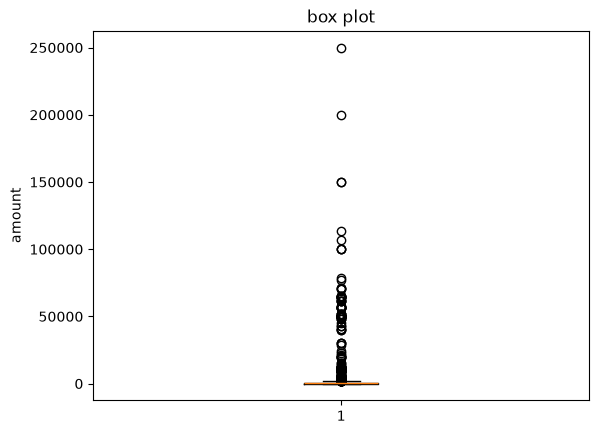

In [61]:
df['year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
num_cols= ['Amount','year','Month','day']
corr = df[num_cols].corr(numeric_only=True)
corr


plt.boxplot(df['Amount'].dropna())
plt.title('box plot')
plt.ylabel('amount')
plt.show()

In [62]:
df[num_cols].corr()

,Amount,year,Month,day
Amount,1.000000,-0.045200,0.036918,0.204313
year,-0.045200,1.000000,-0.138198,-0.038809
Month,0.036918,-0.138198,1.000000,0.039144
day,0.204313,-0.038809,0.039144,1.000000


In [64]:
outliers

,Date,Mode,Category,Amount,Income/Expense,Currency
10,NaT,Saving Bank account 1,Small Cap fund 2,5000.0,Transfer-Out,INR
11,NaT,Saving Bank account 1,Small cap fund 1,5000.0,Transfer-Out,INR
14,NaT,Saving Bank account 1,Other,3500.0,Income,INR
27,NaT,Cash,Family,2000.0,Expense,INR
28,NaT,Saving Bank account 1,Public Provident Fund,12500.0,Transfer-Out,INR
...,...,...,...,...,...,...
2376,NaT,Saving Bank account 1,Other,10000.0,Expense,INR
2435,NaT,Cash,Other,2833.0,Expense,INR
2438,NaT,Cash,Other,2250.0,Expense,INR
2442,NaT,Saving Bank account 1,Other,10000.0,Expense,INR


In [65]:
amount = df['Amount'].dropna()
q1=amount.quantile(0.25)
q3 = amount.quantile(0.75)
iqr =q3-q1
lower = q1-1.5*iqr
upper = q3 + 1.5*iqr
outliers = df[(df['Amount']<lower) | (df['Amount']>upper)]
outliers

,Date,Mode,Category,Amount,Income/Expense,Currency,year,Month,day
10,NaT,Saving Bank account 1,Small Cap fund 2,5000.0,Transfer-Out,INR,NaN,NaN,NaN
11,NaT,Saving Bank account 1,Small cap fund 1,5000.0,Transfer-Out,INR,NaN,NaN,NaN
14,NaT,Saving Bank account 1,Other,3500.0,Income,INR,NaN,NaN,NaN
27,NaT,Cash,Family,2000.0,Expense,INR,NaN,NaN,NaN
28,NaT,Saving Bank account 1,Public Provident Fund,12500.0,Transfer-Out,INR,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2376,NaT,Saving Bank account 1,Other,10000.0,Expense,INR,NaN,NaN,NaN
2435,NaT,Cash,Other,2833.0,Expense,INR,NaN,NaN,NaN
2438,NaT,Cash,Other,2250.0,Expense,INR,NaN,NaN,NaN
2442,NaT,Saving Bank account 1,Other,10000.0,Expense,INR,NaN,NaN,NaN


In [66]:
df.shape

(2461, 9)

In [67]:
df['Amount'] = df['Amount'].clip(lower=lower,upper=upper)
df.shape

(2461, 9)

In [70]:
df[num_cols].corr()

,Amount,year,Month,day
Amount,1.000000,-0.082427,0.070244,0.158789
year,-0.082427,1.000000,-0.138198,-0.038809
Month,0.070244,-0.138198,1.000000,0.039144
day,0.158789,-0.038809,0.039144,1.000000


In [71]:
df.duplicated().sum()

np.int64(670)

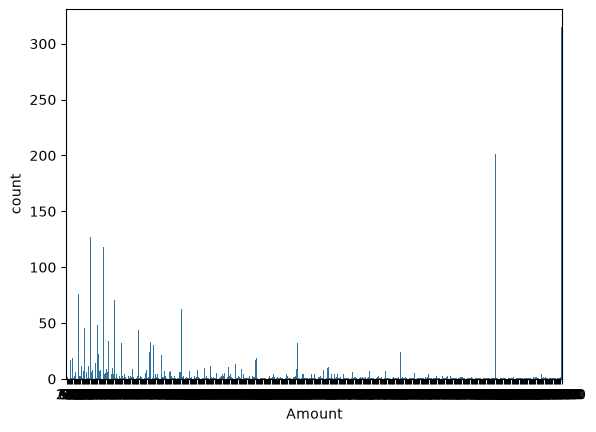

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['Amount'])
plt.show()

(array([1179.,  257.,  168.,   93.,   45.,   52.,   29.,   16.,   19.,
          13.,  212.,   10.,    9.,    6.,   10.,    9.,    5.,    4.,
           4.,  321.]),
 array([   2.  ,   99.15,  196.3 ,  293.45,  390.6 ,  487.75,  584.9 ,
         682.05,  779.2 ,  876.35,  973.5 , 1070.65, 1167.8 , 1264.95,
        1362.1 , 1459.25, 1556.4 , 1653.55, 1750.7 , 1847.85, 1945.  ]),
 <BarContainer object of 20 artists>)

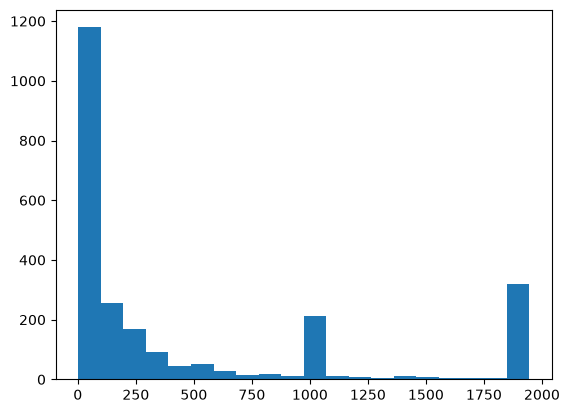

In [76]:
plt.hist(df['Amount'],bins = 20)

C:\Users\Ashwini Wandre\AppData\Local\Temp\ipykernel_2800\2945972173.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Amount'])


<Axes: xlabel='Amount', ylabel='Density'>

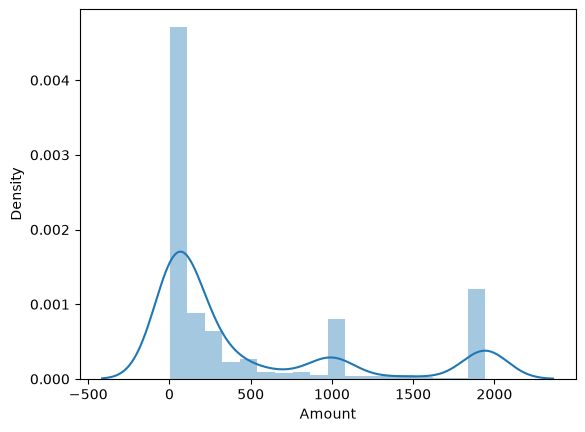

In [77]:
sns.distplot(df['Amount'])

<Axes: ylabel='Amount'>

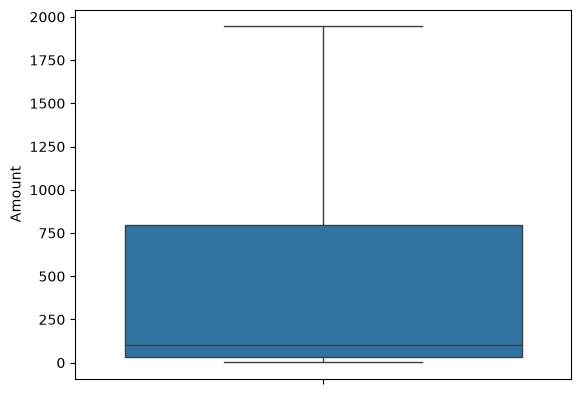

In [78]:
sns.boxplot(df['Amount'])

<Axes: xlabel='Amount', ylabel='year'>

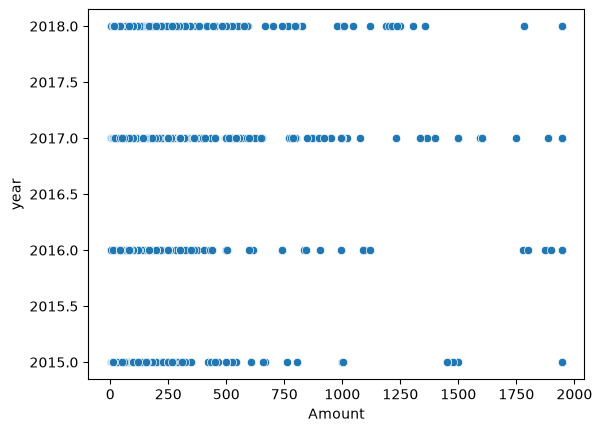

In [83]:
sns.scatterplot(data=df, x='Amount', y='year')

In [ ]:
# pip install sweetviz
import sweetviz as sv
report = sv.analyze(df)
report.show_html()

                                             |          | [  0%]   00:00 -> (? left)

Feature: Mode                                |██        | [ 20%]   00:00 -> (00:03 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: Category                            |███       | [ 30%]   00:02 -> (00:05 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: Amount                              |████      | [ 40%]   00:03 -> (00:05 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [90]:
pip install dtale

  Using cached setuptools-83.0.0-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/17.4 MB ? eta -:--:--
   -- ------------------------------------- 1.0/17.4 MB 6.0 MB/s eta 0:00:03
   --------- ------------------------------ 3.9/17.4 MB 11.0 MB/s eta 0:00:02
   ----------------- ---------------------- 7.6/17.4 MB 13.2 MB/s eta 0:00:01
   ----------------------- ---------------- 10.2/17.4 MB 13.0 MB/s eta 0:00:01
   ----------------------------- ---------- 12.8/17.4 MB 12.9 MB/s eta 0:00:01
   ----------------------------------- ---- 15.5/17.4 MB 12.9 MB/s eta 0:00:01
   ---------------------------------------- 17.4/17.4 MB 12.4 MB/s  0:00:01
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ------------------ --------------------- 4.2/8.9 MB 18.7 MB/s eta 0:00:01
   ----------------------------- ---------- 6.6/8.9 MB 15.8 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 14.0 MB/s  0:00:00
   ----------------

In [91]:
import dtale
d = dtale.show(df)
d.open_browser()

# retraining

import joblib

model = joblib.load("model.pkl")

X_new = new_df.drop("target", axis=1)
y_new = new_df["target"]

model.partial_fit(X_new, y_new)

joblib.dump(model, "model.pkl")